Sampling frequency: 10 Hz
Detected steps: 82


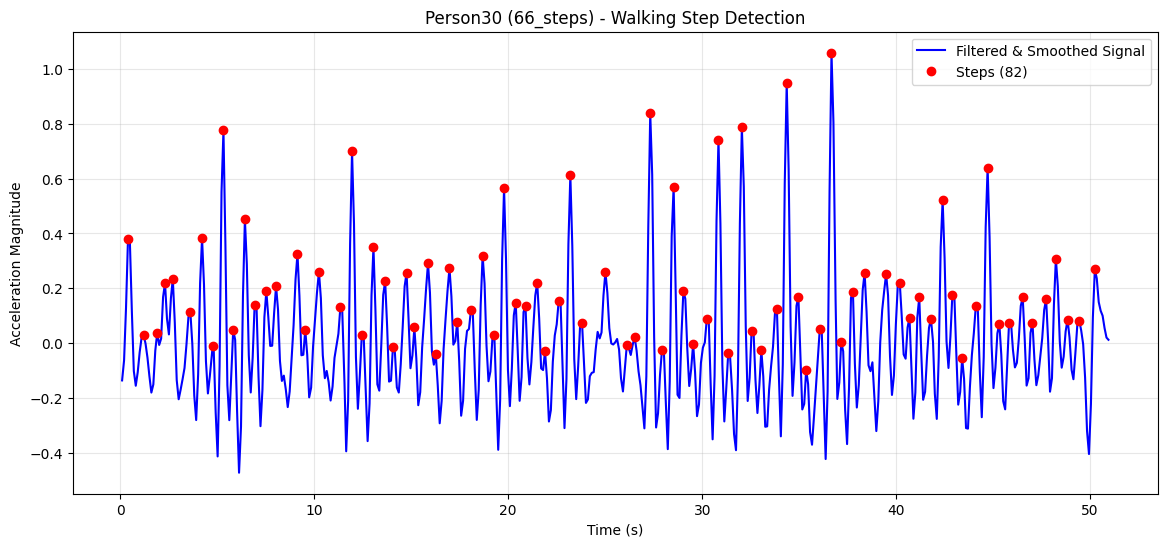

In [2]:
# -----------------------------
# Real-Time Step Counter - Corrected Version
# -----------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks

# -----------------------------
# Load File
# -----------------------------
# File path aur name ko change kiya gaya hai
file_path = "Data/80steps.csv"
df = pd.read_csv(file_path)

# -----------------------------
# Convert time to seconds if needed
# -----------------------------
# Uncomment if 'time' column is in milliseconds
# df['time'] = df['time'] / 1000

# -----------------------------
# Acceleration Magnitude
# -----------------------------
# Headers ko badalkar gFx, gFy, gFz kiya gaya hai (Accelerometer only)
df['acc_mag'] = np.sqrt(df['gFx']**2 + df['gFy']**2 + df['gFz']**2)

# -----------------------------
# Sampling Rate (Hz)
# -----------------------------
fs = 10  # Sample rate ko badalkar 10Hz kiya gaya hai
print(f"Sampling frequency: {fs} Hz")

# -----------------------------
# Butterworth Bandpass Filter
# -----------------------------
def bandpass(data, low, high, fs, order=4):
    nyq = 0.5 * fs
    low_norm = max(0.001, min(low / nyq, 0.999))
    high_norm = max(0.001, min(high / nyq, 0.999))
    b, a = butter(order, [low_norm, high_norm], btype='band')
    return filtfilt(b, a, data)

# Apply Bandpass Filter
df['filtered'] = bandpass(df['acc_mag'], low=0.3, high=3.0, fs=fs)

# -----------------------------
# Smooth the Signal
# -----------------------------
window_size = int(0.3 * fs)  # ~0.3s smoothing window
df['smooth'] = df['filtered'].rolling(window=window_size, center=True, min_periods=1).mean()
signal = df['smooth']

# -----------------------------
# Adaptive Peak Detection
# -----------------------------
prominence_val = max(0.01, 0.15 * np.std(signal))
distance_val = int(fs / 3)  # minimum distance between steps in samples

peaks, _ = find_peaks(signal, distance=distance_val, prominence=prominence_val)

print(f"Detected steps: {len(peaks)}")

# -----------------------------
# Plot Results
# -----------------------------
plt.figure(figsize=(14, 6))
plt.plot(df['time'], signal, label='Filtered & Smoothed Signal', color='blue')
plt.plot(df['time'].iloc[peaks], signal.iloc[peaks], 'ro', label=f"Steps ({len(peaks)})")
plt.xlabel("Time (s)")
plt.ylabel("Acceleration Magnitude")
plt.title("Person30 (66_steps) - Walking Step Detection")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()